In [30]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer,AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit.visualization import plot_histogram

In [5]:
qc = QuantumCircuit(3,3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.measure([0,1,2],[0,1,2])
print(qc)

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


In [34]:
fake_backend = FakeBrisbane()
noise_model_backend = NoiseModel.from_backend(fake_backend)
sim = AerSimulator(noise_model = noise_model_backend)
tqc = transpile(qc,sim)
noise_model_res = sim.run(tqc).result().get_counts()
print(noise_model_res)

{'000': 478, '111': 494, '010': 7, '101': 16, '110': 10, '001': 13, '011': 4, '100': 2}


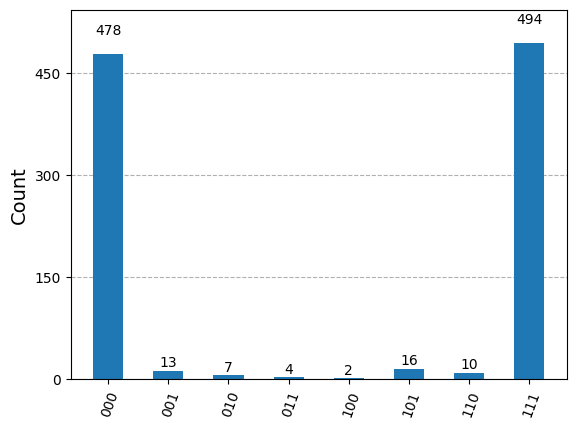

In [35]:
plot_histogram(noise_model_res)

In [ ]:
backend = Aer.get_backend('qasm_simulator')
result = backend.run(qc,shots = 1024).result().get_counts()
print(result)

{'111': 489, '000': 535}


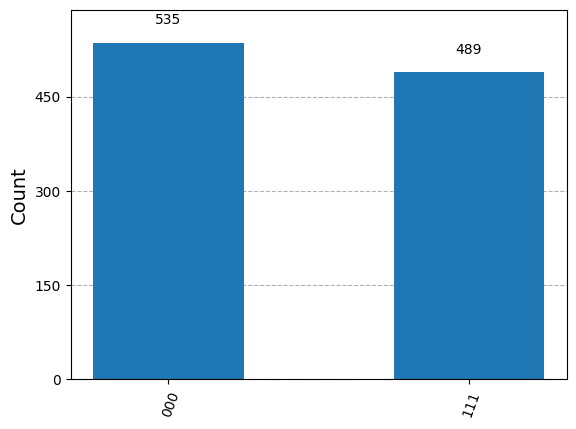

In [26]:
plot_histogram(result)